# Signal Decomposition

## Table of Contents
* [Requirements](#requirements)
* [Data Setup](#data-setup)
* [VMD Optimization](#vmd-optimization)
    * [Central Frequency Analysis](#central-frequency-analysis)
    * [Correlation Analysis](#correlation-analysis)
* [Data Export](#data-export)

----

## Requirements

In [1]:
import sys
from joblib import dump
from pathlib import Path
from functools import reduce

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sktime.transformations.series.vmd import VmdTransformer

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))
import src.fc_analysis as fca

----

## Data Setup

In [2]:
K_dict = np.load('../data/processed/vmd_fc.pkl', allow_pickle=True)

In [3]:
K_list = []
IMF_list = []
fc_list = []
for K in K_dict.keys():
    for IMF in K_dict[K].keys():
        K_list.append(K)
        IMF_list.append(IMF+1)
        fc_list.append(K_dict[K][IMF])
df_fc = pd.DataFrame({'K':K_list, 'IMF':IMF_list, 'fc':fc_list})
print(df_fc.shape)
df_fc.head()

(209, 3)


,K,IMF,fc
0,2,1,0.000236
1,2,2,0.082889
2,3,1,0.000235
3,3,2,0.082875
4,3,3,0.164891


In [4]:
df_fc = reduce(
    lambda l, r:l.merge(r, on='K', how='outer'),
    [fca.find_fc_max(df_fc), fca.find_cfr_min_max(df_fc), fca.find_cfr_roc(df_fc), fca.find_cfr_K(df_fc), fca.find_fc_sd(df_fc)]
).sort_values(by='K', ascending=True)
print(df_fc.shape)
df_fc.head()

(19, 6)


,K,fc_max,CFR (max/min),CFR (RoC),CFR (K/(K-1)),fc_sd
0,2,0.082889,350.801156,NaN,NaN,0.058444
1,3,0.164891,700.731367,1.997517,1.989302,0.082328
2,4,0.370023,1573.557301,2.245593,2.244044,0.158625
3,5,0.414469,1765.200433,1.121790,1.120116,0.159210
4,6,0.415159,1770.212533,1.002839,1.001666,0.149234


In [5]:
corr_dict = np.load('../data/processed/vmd_corr.pkl', allow_pickle=True)
K_list = []
IMF_list = []
corr_list = []
for K in K_dict.keys():
    for IMF in K_dict[K].keys():
        K_list.append(K)
        IMF_list.append(IMF+1)
        corr_list.append(corr_dict[K][IMF])
df_corr = pd.DataFrame({'K':K_list, 'IMF':IMF_list, 'corr':corr_list})
print(df_corr.shape)
df_corr.head()

(209, 3)


,K,IMF,corr
0,2,1,0.950871
1,2,2,0.242793
2,3,1,0.950730
3,3,2,0.241748
4,3,3,0.083672


----

## VMD Optimization

### Central Frequency Analysis

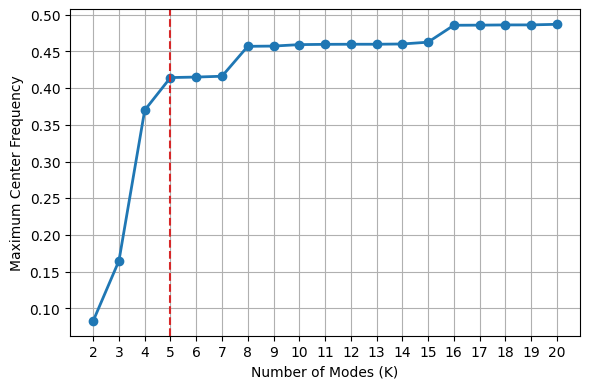

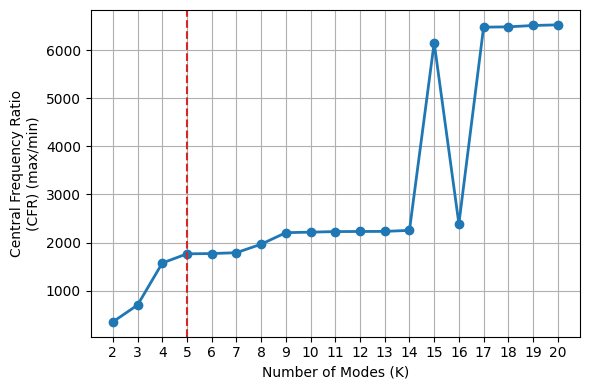

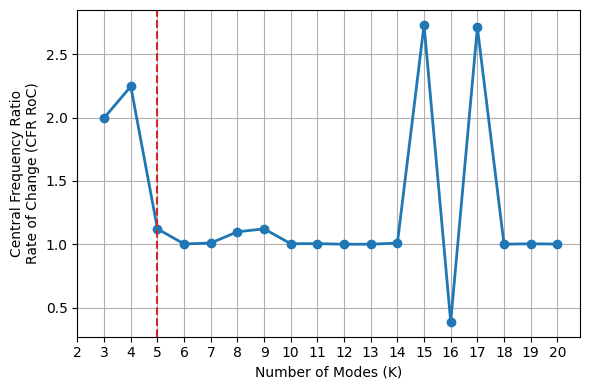

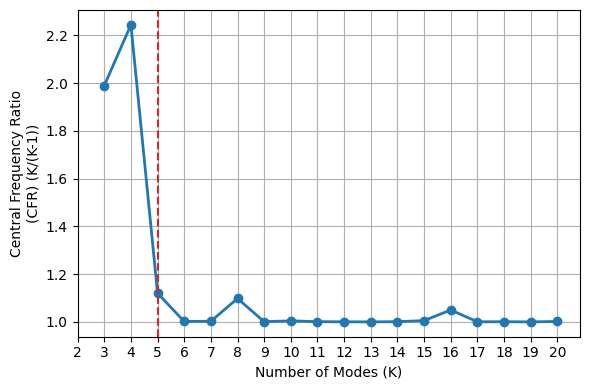

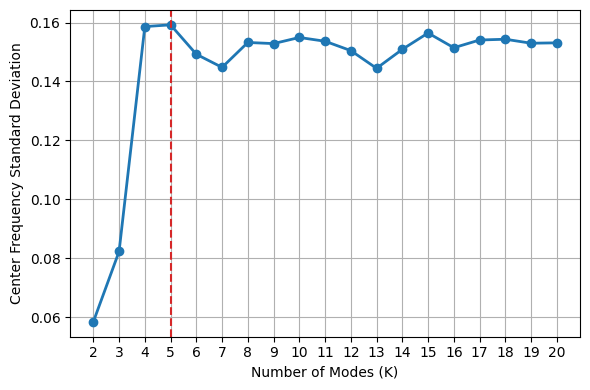

In [6]:
for col, lab in zip(['fc_max', 'CFR (max/min)', 'CFR (RoC)', 'CFR (K/(K-1))', 'fc_sd'], ['Maximum Center Frequency', 'Central Frequency Ratio\n(CFR) (max/min)', 'Central Frequency Ratio\nRate of Change (CFR RoC)', 'Central Frequency Ratio\n(CFR) (K/(K-1))', 'Center Frequency Standard Deviation']):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(df_fc['K'], df_fc[col], c='tab:blue', linewidth=2, marker='o')
    ax.set_ylabel(lab)
    ax.set_xlabel('Number of Modes (K)')
    ax.set_xticks([_ for _ in range(2, 21)])
    ax.grid()
    ax.axvline(5, color='tab:red', linestyle='--')
    fig.tight_layout()
    fig.savefig(f"../results/signal_decomposition/{col.lower().replace(' ', '_').replace('/', '_')}.svg", dpi=400)
    plt.show()

### Correlation Analysis

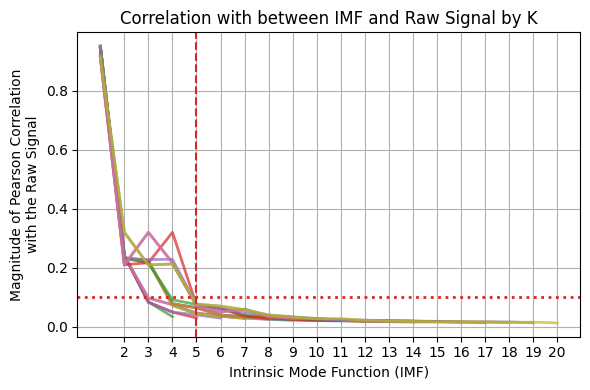

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.lineplot(data=df_corr, x='IMF', y='corr', hue='K', palette='tab10', alpha=0.7, linewidth=2, legend=False)
ax.set_ylabel('Magnitude of Pearson Correlation\nwith the Raw Signal')
ax.set_xlabel('Intrinsic Mode Function (IMF)')
ax.set_title('Correlation with between IMF and Raw Signal by K')
ax.set_xticks([_ for _ in range(2, 21)])
ax.grid()
ax.axhline(0.1, linestyle=':', color='tab:red', linewidth=2)
ax.axvline(5, color='tab:red', linestyle='--')
fig.tight_layout()
fig.savefig(f'../results/signal_decomposition/imf_correlation.svg', dpi=400)
plt.show()

----

## Data Export

In [14]:
df = pd.read_pickle('../data/processed/df_train_val.pkl')

for split, (val_start, val_end) in enumerate((
    ('2023-01-01 00:00:00+00:00', '2023-04-30 23:00:00+00:00'),
    ('2023-05-01 00:00:00+00:00', '2023-08-31 23:00:00+00:00'),
    ('2023-09-01 00:00:00+00:00', '2023-12-31 23:00:00+00:00')
    )):

    train_start = '2019-01-01 00:00:00+00:00'
    train_end = pd.to_datetime(val_start) - pd.Timedelta(hours=1)

    price_train = df.loc[train_start:train_end]['price'].to_numpy()
    price_val = df.loc[val_start:val_end]['price'].to_numpy()

    vmd = VmdTransformer(K=5, alpha=4_000)
    imfs_train = vmd.fit_transform(price_train)
    resid_train = price_train - imfs_train.sum(axis=1)
    imfs_val = vmd.transform(price_val)
    resid_val = price_val - imfs_val.sum(axis=1)

    train_concat_list, val_concat_list = [], []
    for i in range(0, 5):
        ss = StandardScaler()
        train_concat_list.append(ss.fit_transform(imfs_train[:, i].reshape(-1, 1)))
        val_concat_list.append(ss.transform(imfs_val[:, i].reshape(-1, 1)))
        dump(ss, f'../models/scalers/ss_split{split+1}_imf{i+1}.pkl')

    ss = StandardScaler()
    train_concat_list.append(ss.fit_transform(resid_train.reshape(-1, 1)))
    val_concat_list.append(ss.transform(resid_val.reshape(-1, 1)))
    dump(ss, f'../models/scalers/ss_split{split+1}_resid.pkl')

    m_train = np.concat(train_concat_list, axis=1)
    m_val = np.concat(val_concat_list, axis=1)
    dump(m_train, f'../data/processed/np_split{split+1}_train_imf_.pkl')
    dump(m_val, f'../data/processed/np_split{split+1}_val_imf.pkl')